<a href="https://colab.research.google.com/github/Sejal14-tech/auto_tagging/blob/main/eda.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# EDA

## Exploratory Data Analysis (EDA) for Auto-Tagging

This notebook performs comprehensive exploratory data analysis on Stack Overflow questions and tags data to prepare it for automatic tagging model training.

### Objectives:
- Understand data structure and quality
- Analyze tag distributions and frequencies
- Clean and preprocess text data
- Create final dataset for model training
- Identify key insights for model design

### Dataset:
- Questions.csv: Contains question titles, bodies, scores, and IDs
- Tags.csv: Contains tag assignments for each question

In [172]:

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import nltk
import re
import string
import time
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import MultiLabelBinarizer
from wordcloud import WordCloud
from google.colab import drive

!pip install contractions
import contractions
pd.options.mode.chained_assignment = None

start_time = time.time()
drive.mount('/content/drive')
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('punkt_tab')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

## Step 1: Setup and Imports

Import all necessary libraries for data analysis, text processing, and visualization. This includes NLTK for text processing, BeautifulSoup for HTML parsing, and various ML libraries.

In [173]:
data1 = pd.read_csv('Tags.csv')

## Step 2: Data Loading

Load the raw datasets: Tags.csv and Questions.csv. These contain the basic data that will be merged and analyzed.

In [174]:
data1

,Id,Tag
0,80,flex
1,80,actionscript-3
2,80,air
3,90,svn
4,90,tortoisesvn
...,...,...
3750989,40143360,javascript
3750990,40143360,vue.js
3750991,40143380,npm
3750992,40143380,mocha


In [175]:
data2 = pd.read_csv(
    'Questions.csv',
    encoding='latin-1',
    on_bad_lines='skip',
    engine='python'
)

In [176]:
data2['Id'].value_counts()

,count
Id,
30327730,1
80,1
90,1
120,1
180,1
...,...
1070,1
1040,1
1010,1


In [177]:

data1['Tag'] = data1['Tag'].astype(str)
data = pd.merge(data2, data1, how='inner', on='Id')


## Step 3: Data Merging and Initial Processing

Merge the questions and tags data on question ID. Convert tags to proper format and handle data aggregation for questions with multiple tags.

In [178]:
data['Id'].value_counts()

,count
Id,
24591900,5
10817670,5
10817610,5
10817540,5
10818160,5
...,...
6700570,1
26962470,1
26962350,1


In [179]:
data

Id  OwnerUserId          CreationDate            ClosedDate  \
0              80         26.0  2008-08-01T13:57:07Z                   NaN   
1              80         26.0  2008-08-01T13:57:07Z                   NaN   
2              80         26.0  2008-08-01T13:57:07Z                   NaN   
3              90         58.0  2008-08-01T14:41:24Z  2012-12-26T03:45:49Z   
4              90         58.0  2008-08-01T14:41:24Z  2012-12-26T03:45:49Z   
...           ...          ...                   ...                   ...   
2681666  30327700    3730854.0  2015-05-19T13:53:25Z                   NaN   
2681667  30327730    4460846.0  2015-05-19T13:54:40Z                   NaN   
2681668  30327730    4460846.0  2015-05-19T13:54:40Z                   NaN   
2681669  30327730    4460846.0  2015-05-19T13:54:40Z                   NaN   
2681670  30327730    4460846.0  2015-05-19T13:54:40Z                   NaN   

         Score  \
0           26   
1           26   
2           26   
3          144   
4          144   
...        ...   
2681666      1   
2681667      3   
2681668      3   
2681669      3   
2681670      3   

                                                                                  Title  \
0                            SQLStatement.execute() - multiple queries in one statement   
1                            SQLStatement.execute() - multiple queries in one statement   
2                            SQLStatement.execute() - multiple queries in one statement   
3                                 Good branching and merging tutorials for TortoiseSVN?   
4                                 Good branching and merging tutorials for TortoiseSVN?   
...                                                                                 ...   
2681666  How do I get the actual monitor name in JAVA? As seen in the resolution dialog   
2681667                                      NullPointerException in CustomArrayAdapter   
2681668                                      NullPointerException in CustomArrayAdapter   
2681669                                      NullPointerException in CustomArrayAdapter   
2681670                                      NullPointerException in CustomArrayAdapter   

                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                        

In [180]:
data = data.groupby(['Id','Score', 'Title','Body']).agg({'Tag': lambda x: ', '.join(x)}).reset_index()


In [181]:
data

,Id,Score,Title,Body,Tag
0,80,26,SQLStatement.execute() - multiple queries in one statement,"<p>I've written a database generation script in <a href=""http://en.wikipedia.org/wiki/SQL"">SQL</a> and want to execute it in my <a href=""http://en.wikipedia.org/wiki/Adobe_Integrated_Runtime"">Adobe AIR</a> application:</p>\n\n<pre><code>Create Table tRole (\n roleID integer Primary Key\n ,roleName varchar(40)\n);\nCreate Table tFile (\n fileID integer Primary Key\n ,fileName varchar(50)\n ,fileDescription varchar(500)\n ,thumbnailID integer\n ,fileFormatID integer\n ,categoryID integer\n ,isFavorite boolean\n ,dateAdded date\n ,globalAccessCount integer\n ,lastAccessTime date\n ,downloadComplete boolean\n ,isNew boolean\n ,isSpotlight boolean\n ,duration varchar(30)\n);\nCreate Table tCategory (\n categoryID integer Primary Key\n ,categoryName varchar(50)\n ,parent_categoryID integer\n);\n...\n</code></pre>\n\n<p>I execute this in Adobe AIR using the following methods:</p>\n\n<pre><code>public static function RunSqlFromFile(fileName:String):void {\n var file:File = File.applicationDirectory.resolvePath(fileName);\n var stream:FileStream = new FileStream();\n stream.open(file, FileMode.READ)\n var strSql:String = stream.readUTFBytes(stream.bytesAvailable);\n NonQuery(strSql);\n}\n\npublic static function NonQuery(strSQL:String):void\n{\n var sqlConnection:SQLConnection = new SQLConnection();\n sqlConnection.open(File.applicationStorageDirectory.resolvePath(DBPATH);\n var sqlStatement:SQLStatement = new SQLStatement();\n sqlStatement.text = strSQL;\n sqlStatement.sqlConnection = sqlConnection;\n try\n {\n sqlStatement.execute();\n }\n catch (error:SQLError)\n {\n Alert.show(error.toString());\n }\n}\n</code></pre>\n\n<p>No errors are generated, however only <code>tRole</code> exists. It seems that it only looks at the first query (up to the semicolon- if I remove it, the query fails). Is there a way to call multiple queries in one statement?</p>\n","flex, actionscript-3, air"
1,90,144,Good branching and merging tutorials for TortoiseSVN?,"<p>Are there any really good tutorials explaining <a href=""http://svnbook.red-bean.com/en/1.8/svn.branchmerge.html"" rel=""nofollow"">branching and merging</a> with Apache Subversion? </p>\n\n<p>All the better if it's specific to TortoiseSVN client.</p>\n","svn, tortoisesvn, branch, branching-and-merging"
2,120,21,ASP.NET Site Maps,"<p>Has anyone got experience creating <strong>SQL-based ASP.NET</strong> site-map providers?</p>\n\n<p>I've got the default XML file <code>web.sitemap</code> working properly with my Menu and <strong>SiteMapPath</strong> controls, but I'll need a way for the users of my site to create and modify pages dynamically.</p>\n\n<p>I need to tie page viewing permissions into the standard <code>ASP.NET</code> membership system as well.</p>\n","sql, asp.net, sitemap"
3,180,53,Function for creating color wheels,"<p>This is something I've pseudo-solved many times and never quite found a solution. That's stuck with me. The problem is to come up with a way to generate <code>N</code> colors, that are as distinguishable as possible where <code>N</code> is a parameter.</p>\n","algorithm, language-agnostic, colors, color-space"
4,260,49,Adding scripting functionality to .NET applications,"<p>I have a little game written in C#. It uses a database as back-end. It's \na <a href=""http://en.wikipedia.org/wiki/Collectible_card_game"">trading card game</a>, and I wanted to implement the function of the cards as a script.</p>\n\n<p>What I mean is that I essentially have an interface, <code>ICard</code>, which a card class implements (<code>public class Card056 : ICard</code>) and which contains function that are called by the game.</p>\n\n<p>Now, to make the thing maintainable/moddable, I would like to have the class for each card as source code in the database and essentially compile it on first use. So when I have to add/change a card, I'll just add it to the database and tell my application 

In [182]:
data['Tag'] = data['Tag'].apply(lambda x: x.split(', '))
data.head()


,Id,Score,Title,Body,Tag
0,80,26,SQLStatement.execute() - multiple queries in one statement,"<p>I've written a database generation script in <a href=""http://en.wikipedia.org/wiki/SQL"">SQL</a> and want to execute it in my <a href=""http://en.wikipedia.org/wiki/Adobe_Integrated_Runtime"">Adobe AIR</a> application:</p>\n\n<pre><code>Create Table tRole (\n roleID integer Primary Key\n ,roleName varchar(40)\n);\nCreate Table tFile (\n fileID integer Primary Key\n ,fileName varchar(50)\n ,fileDescription varchar(500)\n ,thumbnailID integer\n ,fileFormatID integer\n ,categoryID integer\n ,isFavorite boolean\n ,dateAdded date\n ,globalAccessCount integer\n ,lastAccessTime date\n ,downloadComplete boolean\n ,isNew boolean\n ,isSpotlight boolean\n ,duration varchar(30)\n);\nCreate Table tCategory (\n categoryID integer Primary Key\n ,categoryName varchar(50)\n ,parent_categoryID integer\n);\n...\n</code></pre>\n\n<p>I execute this in Adobe AIR using the following methods:</p>\n\n<pre><code>public static function RunSqlFromFile(fileName:String):void {\n var file:File = File.applicationDirectory.resolvePath(fileName);\n var stream:FileStream = new FileStream();\n stream.open(file, FileMode.READ)\n var strSql:String = stream.readUTFBytes(stream.bytesAvailable);\n NonQuery(strSql);\n}\n\npublic static function NonQuery(strSQL:String):void\n{\n var sqlConnection:SQLConnection = new SQLConnection();\n sqlConnection.open(File.applicationStorageDirectory.resolvePath(DBPATH);\n var sqlStatement:SQLStatement = new SQLStatement();\n sqlStatement.text = strSQL;\n sqlStatement.sqlConnection = sqlConnection;\n try\n {\n sqlStatement.execute();\n }\n catch (error:SQLError)\n {\n Alert.show(error.toString());\n }\n}\n</code></pre>\n\n<p>No errors are generated, however only <code>tRole</code> exists. It seems that it only looks at the first query (up to the semicolon- if I remove it, the query fails). Is there a way to call multiple queries in one statement?</p>\n","[flex, actionscript-3, air]"
1,90,144,Good branching and merging tutorials for TortoiseSVN?,"<p>Are there any really good tutorials explaining <a href=""http://svnbook.red-bean.com/en/1.8/svn.branchmerge.html"" rel=""nofollow"">branching and merging</a> with Apache Subversion? </p>\n\n<p>All the better if it's specific to TortoiseSVN client.</p>\n","[svn, tortoisesvn, branch, branching-and-merging]"
2,120,21,ASP.NET Site Maps,"<p>Has anyone got experience creating <strong>SQL-based ASP.NET</strong> site-map providers?</p>\n\n<p>I've got the default XML file <code>web.sitemap</code> working properly with my Menu and <strong>SiteMapPath</strong> controls, but I'll need a way for the users of my site to create and modify pages dynamically.</p>\n\n<p>I need to tie page viewing permissions into the standard <code>ASP.NET</code> membership system as well.</p>\n","[sql, asp.net, sitemap]"
3,180,53,Function for creating color wheels,"<p>This is something I've pseudo-solved many times and never quite found a solution. That's stuck with me. The problem is to come up with a way to generate <code>N</code> colors, that are as distinguishable as possible where <code>N</code> is a parameter.</p>\n","[algorithm, language-agnostic, colors, color-space]"
4,260,49,Adding scripting functionality to .NET applications,"<p>I have a little game written in C#. It uses a database as back-end. It's \na <a href=""http://en.wikipedia.org/wiki/Collectible_card_game"">trading card game</a>, and I wanted to implement the function of the cards as a script.</p>\n\n<p>What I mean is that I essentially have an interface, <code>ICard</code>, which a card class implements (<code>public class Card056 : ICard</code>) and which contains function that are called by the game.</p>\n\n<p>Now, to make the thing maintainable/moddable, I would like to have the class for each card as source code in the database and essentially compile it on first use. So when I have to add/change a card, I'll just add it to the database and tell my appl

In [183]:
len(data)

907945

In [184]:
data.dropna(subset=['Tag'], inplace=True)
data.reset_index(drop=True, inplace=True)
print(f"Shape of DataFrame after dropping nulls in 'Tag': {data.shape}")

Shape of DataFrame after dropping nulls in 'Tag': (907945, 5)


In [185]:
data['Score'].describe()

,Score
count,907945.000000
mean,2.272077
std,16.022428
min,-73.000000
25%,0.000000
50%,1.000000
75%,2.000000
max,5190.000000


## Step 4: Score Analysis

Analyze the score distribution of questions. Most questions have positive scores, with very few having zero or negative scores. This helps understand data quality and potential filtering criteria.

In [186]:
print('Only ' + str((data['Score']<0).sum()) + ' questions have negative Score.')
print('Only ' + str((data['Score']==0).sum()) + ' questions have zero Score.')
print('Only ' + str((data['Score']>0).sum()) + ' questions have positive Score.')
print('Only ' + str((data['Score']>5).sum()) + ' questions have Score greater than 5.')

Only 46767 questions have negative Score.
Only 392707 questions have zero Score.
Only 468471 questions have positive Score.
Only 67912 questions have Score greater than 5.


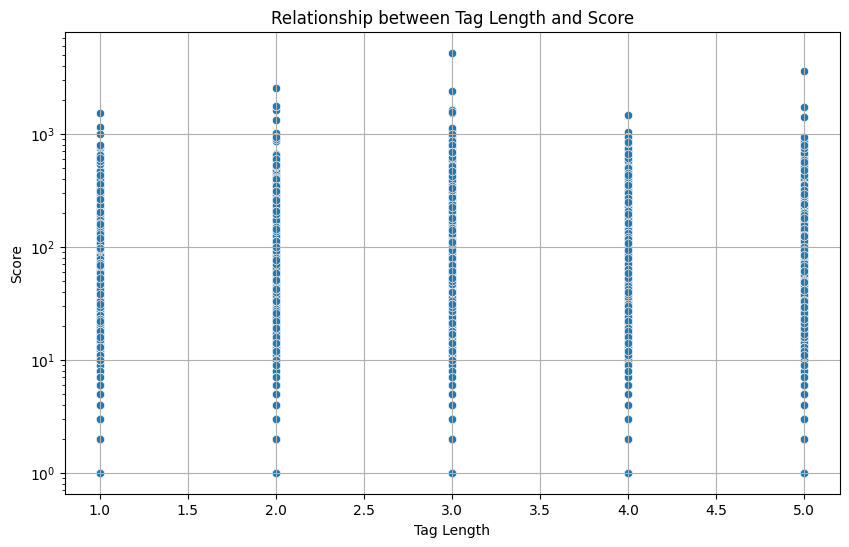

In [187]:
data['Tag_Length'] = data['Tag'].apply(len)

plt.figure(figsize=(10, 6))
sns.scatterplot(x='Tag_Length', y='Score', data=data)
plt.yscale('log')
plt.title('Relationship between Tag Length and Score')
plt.xlabel('Tag Length')
plt.ylabel('Score')
plt.grid(True)
plt.show()

## Step 5: Tag Analysis and Visualizations

Analyze tag distributions, frequencies, and relationships. This includes:
- Tag length vs score relationships
- Most frequent individual tags
- Tag combination frequencies
- Coverage analysis for different numbers of top tags

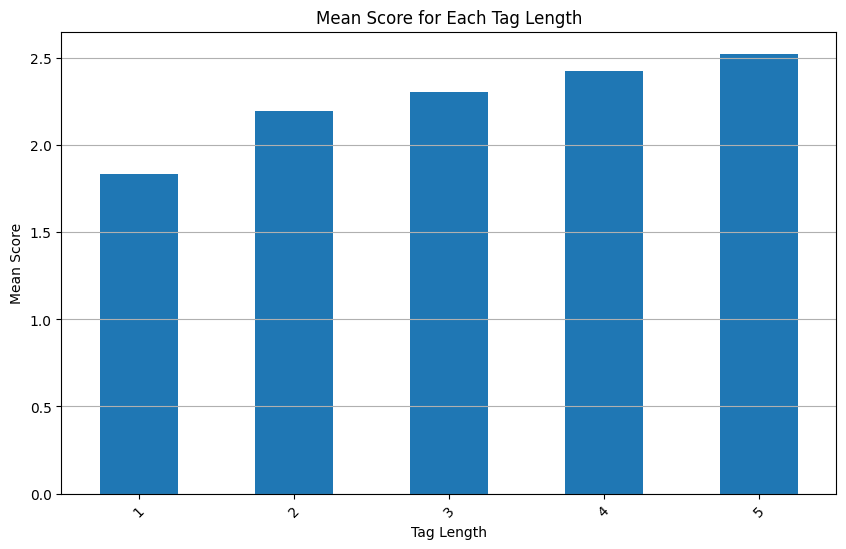

In [188]:
mean_scores = data.groupby('Tag_Length')['Score'].mean()

plt.figure(figsize=(10, 6))
mean_scores.plot(kind='bar')
plt.title('Mean Score for Each Tag Length')
plt.xlabel('Tag Length')
plt.ylabel('Mean Score')
plt.xticks(rotation=45)
plt.grid(axis='y')
plt.show()

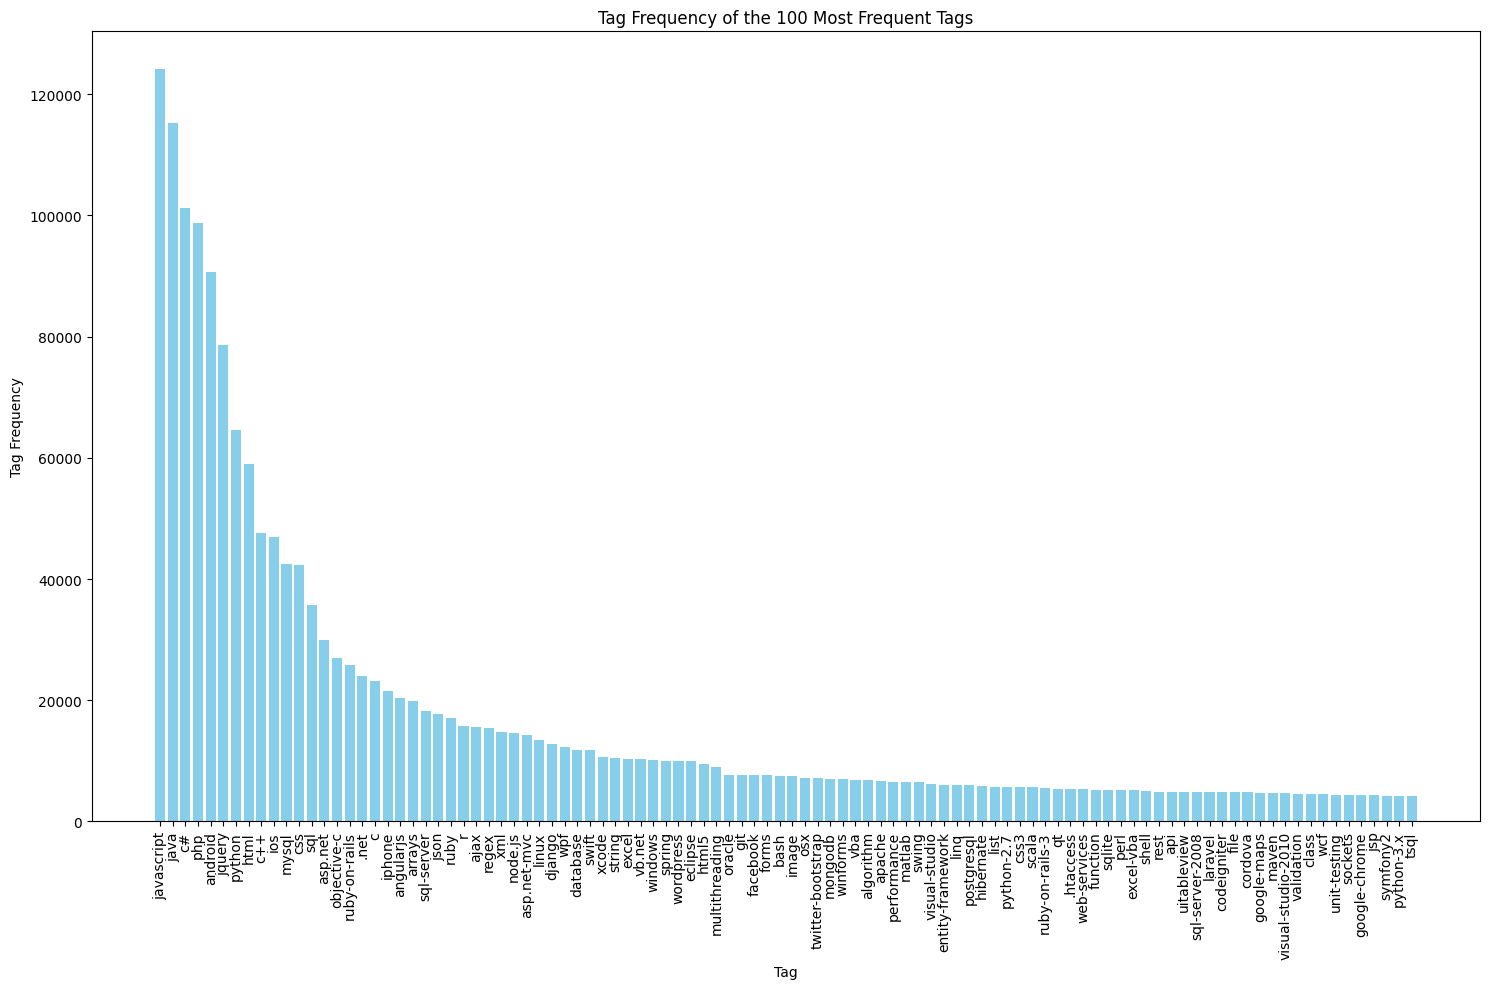

In [189]:

N = 100
tag_frequencies = data1['Tag'].value_counts().head(N)

plt.figure(figsize=(15, 10))
plt.bar(tag_frequencies.index, tag_frequencies, color='skyblue')
plt.xlabel('Tag')
plt.ylabel('Tag Frequency')
plt.title('Tag Frequency of the {} Most Frequent Tags'.format(N))
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

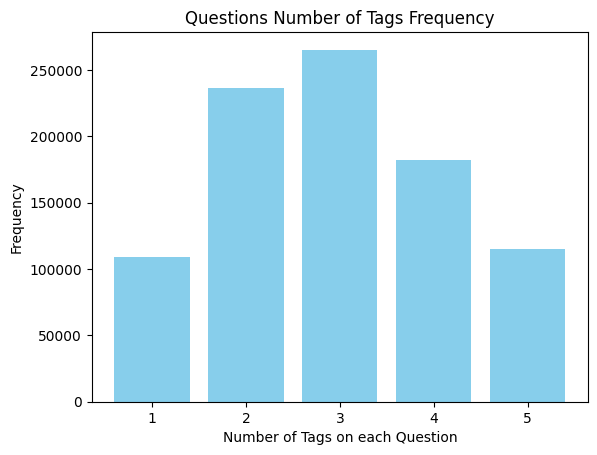

In [190]:

statistics = data['Tag_Length'].value_counts().sort_index()

plt.bar(statistics.index, statistics.values, color='skyblue')
plt.xlabel('Number of Tags on each Question')
plt.ylabel('Frequency')
plt.title('Questions Number of Tags Frequency')
plt.xticks(statistics.index)
plt.show()

In [191]:

print('The Average Number of Tags per Question is',"{:.2f}".format(sum(data['Tag_Length'].values)*1.0/(len(data['Tag_Length'].values)),2), 'tags')

The Average Number of Tags per Question is 2.95 tags


In [192]:

total_unique_tags = len(data1['Tag'].unique())
print("Total Unique Tags:", total_unique_tags)

Total Unique Tags: 37035


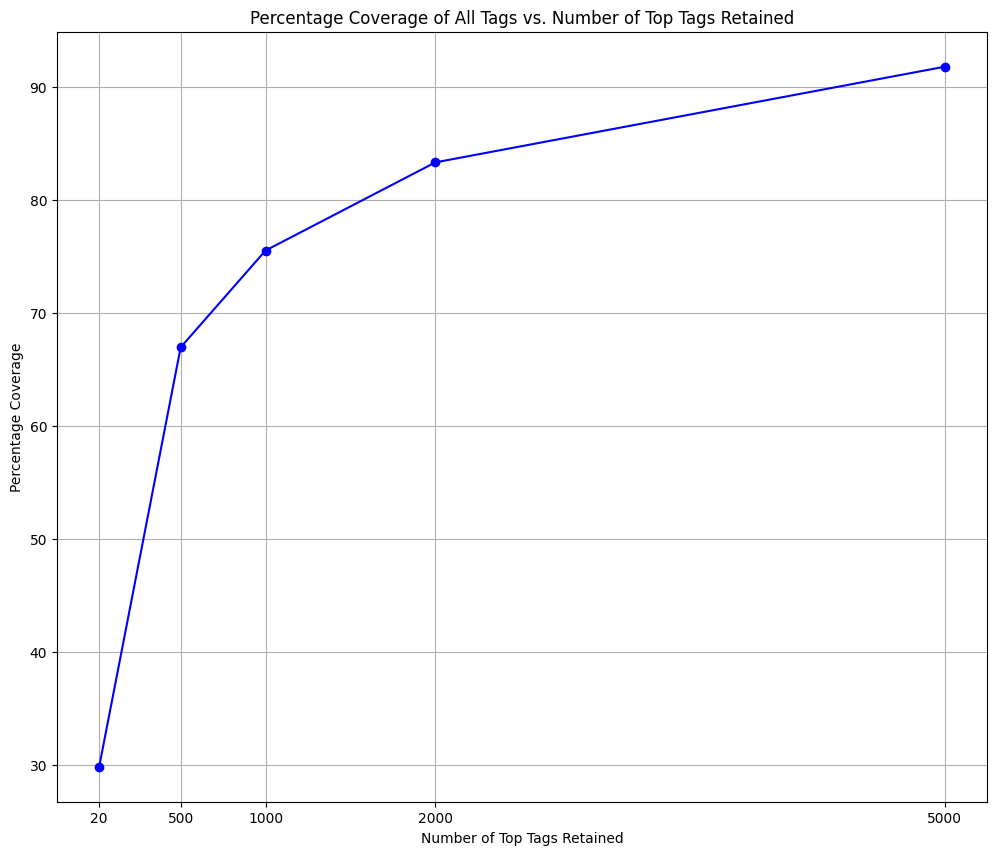

In [193]:

tag_frequencies = data1['Tag'].value_counts()
N_values = [20,500,1000,2000,5000]

coverage_values = []
total_entries = len(data1)
for N in N_values:
    top_N_tags = tag_frequencies.head(N)
    total_frequency = top_N_tags.sum()
    coverage = (total_frequency / total_entries) * 100
    coverage_values.append(coverage)

plt.figure(figsize=(12, 10))
plt.plot(N_values, coverage_values, marker='o', linestyle='-', color='blue')
plt.xlabel('Number of Top Tags Retained')
plt.ylabel('Percentage Coverage')
plt.title('Percentage Coverage of All Tags vs. Number of Top Tags Retained')
plt.grid(True)
plt.xticks(N_values)
plt.show()

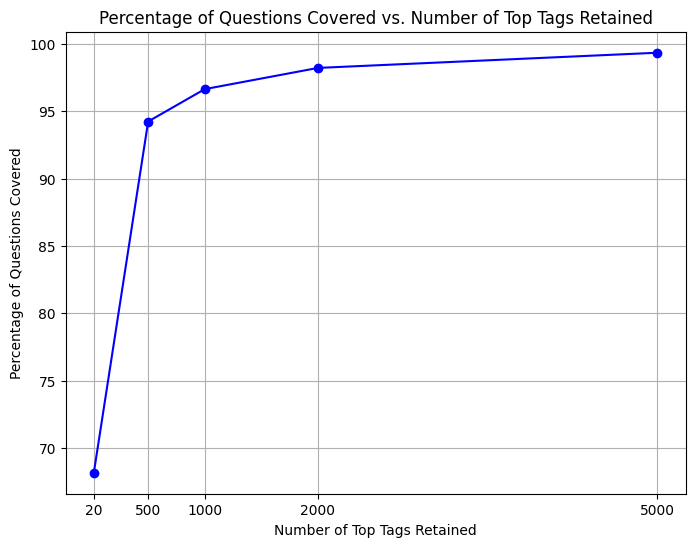

In [194]:
questions_coverage = []
total_questions = len(data)

for N in N_values:
    top_N_tags = tag_frequencies.head(N).index.tolist()
    # Filter to include only questions with top N tags
    filtered_df = data[data['Tag'].apply(lambda x: any(tag in x for tag in top_N_tags))]

    unique_questions = filtered_df['Id'].nunique()
    coverage_percentage = (unique_questions / total_questions) * 100
    questions_coverage.append(coverage_percentage)

plt.figure(figsize=(8, 6))
plt.plot(N_values, questions_coverage, marker='o', linestyle='-', color='blue')
plt.xlabel('Number of Top Tags Retained')
plt.ylabel('Percentage of Questions Covered')
plt.title('Percentage of Questions Covered vs. Number of Top Tags Retained')
plt.grid(True)
plt.xticks(N_values)
plt.show()

In [195]:

data['Tag'] = data['Tag'].apply(sorted)
data['Tag_Tuple'] = data['Tag'].apply(tuple)
tag_combinations = data.groupby('Tag_Tuple').size().reset_index(name='Count')
tag_combinations = tag_combinations.sort_values(by='Count', ascending=False)
tag_combinations

,Tag_Tuple,Count
48731,"(android,)",7410
475418,"(php,)",5238
427912,"(javascript, jquery)",5112
414812,"(java,)",5015
427583,"(javascript,)",4610
...,...,...
18,"(.app, java, osx, working-directory)",1
17,"(.app, java, osx, swing)",1
16,"(.app, java, osx, plist)",1
15,"(.app, installer, mono, monomac)",1


## Step 6: Tag Combination Analysis

Analyze frequent tag combinations to understand common patterns. Focus on top 30 combinations which cover significant portion of the data. This informs the model design for multi-label classification.

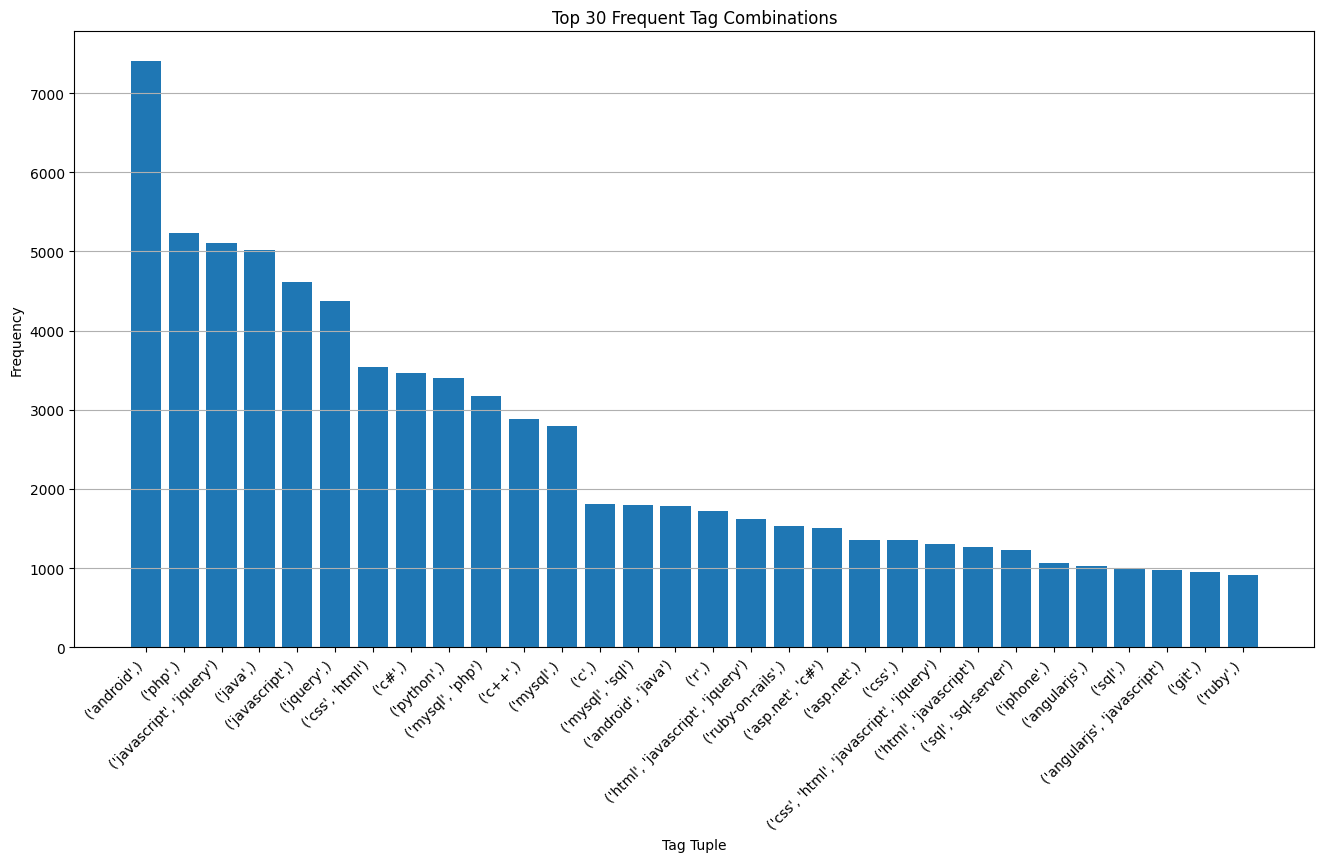

In [196]:

F = 30
top_F_df = tag_combinations.head(F).copy()
top_F_df['Tag_Tuple_str'] = top_F_df['Tag_Tuple'].astype(str)

plt.figure(figsize=(16, 8))
plt.bar(top_F_df['Tag_Tuple_str'], top_F_df['Count'])
plt.title(f'Top {F} Frequent Tag Combinations')
plt.xlabel('Tag Tuple')
plt.ylabel('Frequency')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y')
plt.show()

In [197]:
max = 30
top_tag_combinations = tag_combinations.head(max)
sum_count = top_tag_combinations['Count'].sum()
all_tags = [tag for tag_tuple in top_tag_combinations['Tag_Tuple'] for tag in tag_tuple]
num_unique_tags = len(set(all_tags))

print(f"Number of Questions of Top {max} Tag Combinations: {sum_count}")
print(f"Number of unique tags of Top {max} Tag Combinations: {num_unique_tags}")
print(f"Minimum Frequency of Top {max} Tag Combinations: {top_tag_combinations['Count'].iloc[-1]}\n")

top_tag_combinations


Number of Questions of Top 30 Tag Combinations: 75256
Number of unique tags of Top 30 Tag Combinations: 21
Minimum Frequency of Top 30 Tag Combinations: 918



,Tag_Tuple,Count
48731,"(android,)",7410
475418,"(php,)",5238
427912,"(javascript, jquery)",5112
414812,"(java,)",5015
427583,"(javascript,)",4610
436575,"(jquery,)",4377
270676,"(css, html)",3535
175572,"(c#,)",3468
482109,"(python,)",3406
461463,"(mysql, php)",3176


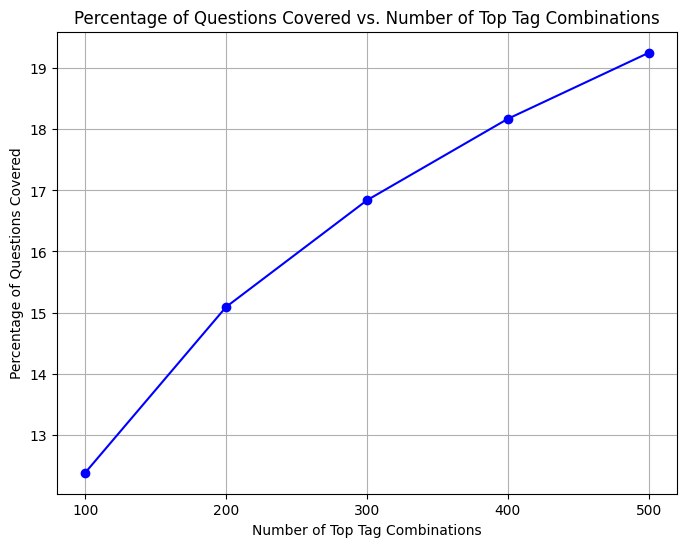

In [198]:
questions_coverage = []
total_questions = len(data)
D_values = range(100,600,100)

for D in D_values:
    top_D_tags_count = tag_combinations.head(D)['Count'].sum()
    coverage_percentage = (top_D_tags_count / total_questions) * 100
    questions_coverage.append(coverage_percentage)

plt.figure(figsize=(8, 6))
plt.plot(D_values, questions_coverage, marker='o', linestyle='-', color='blue')
plt.xlabel('Number of Top Tag Combinations')
plt.ylabel('Percentage of Questions Covered')
plt.title('Percentage of Questions Covered vs. Number of Top Tag Combinations')
plt.grid(True)
plt.xticks(D_values)
plt.show()


In [199]:


top_tag_tuples = set(top_tag_combinations['Tag_Tuple'])
data = data[data['Tag_Tuple'].apply(lambda x: x in top_tag_tuples)]

## Step 7: Data Filtering

Filter the dataset to focus on high-quality data:
- Keep only questions with top 30 tag combinations
- Remove questions with zero or negative scores
- This ensures model trains on relevant, well-tagged questions

In [200]:
def calculate_unique_tags(temp_df):
    all_tags = [tag for tags_list in temp_df['Tag'] for tag in tags_list]
    total_unique_tags = len(set(all_tags))
    print("Total number of unique tags:", total_unique_tags)

calculate_unique_tags(data)
print('Number of Questions:', data.shape[0])

Total number of unique tags: 21
Number of Questions: 75256


In [201]:
data = data[data['Score']>0]

In [202]:
len(data)

31524

In [203]:

P = 3
data['Text'] = (data['Title'] + " ") * P + data['Body']
final_df = data[['Text', 'Tag']].copy()
display(final_df.head(6))

,Text,Tag
11,"How to get the value of built, encoded ViewState? How to get the value of built, encoded ViewState? How to get the value of built, encoded ViewState? <p>I need to grab the base64-encoded representation of the ViewState. Obviously this would not be available until fairly late in the request lifecycle, which is OK.</p>\n\n<p>For example, if the output of the page includes:</p>\n\n<pre><code>&lt;input type=""hidden"" name=""__VIEWSTATE"" \n id=""__VIEWSTATE"" value=""/wEPDwUJODU0Njc5MD...=="" /&gt;\n</code></pre>\n\n<p>I need a way on the server side to get the value <code>""/wEPDwUJODU0Njc5MD...==""</code></p>\n\n<p>To clarify, I need this value when the page is being rendered, not on PostBack. e.g. I need to know the ViewState value that is being <em>sent</em> to the client, not the ViewState I'm getting back from them.</p>\n","[asp.net, c#]"
23,"Convert HashBytes to VarChar Convert HashBytes to VarChar Convert HashBytes to VarChar <p>I want to get the MD5 Hash of a string value in SQL Server 2005. I do this with the following command:</p>\n\n<pre><code>SELECT HashBytes('MD5', 'HelloWorld')\n</code></pre>\n\n<p>However, this returns a VarBinary instead of a VarChar value. If I attempt to convert <code>0x68E109F0F40CA72A15E05CC22786F8E6</code> into a VarChar I get <code>hÃ¡ Ã°Ã´Â§*Ã \Ã'â Ã¸Ã¦</code> instead of <code>68E109F0F40CA72A15E05CC22786F8E6</code>.</p>\n\n<p>Is there any SQL-based solution?</p>\n\n<p><strong><a href=""http://stackoverflow.com/questions/2120/#2382"">Yes</a></strong></p>\n","[sql, sql-server]"
34,"MySQL/Apache Error in PHP MySQL query MySQL/Apache Error in PHP MySQL query MySQL/Apache Error in PHP MySQL query <p>I am getting the following error:</p>\n\n<blockquote>\n <p>Access denied for user 'apache'@'localhost' (using password: NO)</p>\n</blockquote>\n\n<p>When using the following code:</p>\n\n<pre><code>&lt;?php\n\ninclude(""../includes/connect.php"");\n\n$query = ""SELECT * from story"";\n\n$result = mysql_query($query) or die(mysql_error());\n\necho ""&lt;h1&gt;Delete Story&lt;/h1&gt;"";\n\nif (mysql_num_rows($result) &gt; 0) {\n while($row = mysql_fetch_row($result)){\n echo '&lt;b&gt;'.$row[1].'&lt;/b&gt;&lt;span align=""right""&gt;&lt;a href=""../process/delete_story.php?id='.$row[0].'""&gt;Delete&lt;/a&gt;&lt;/span&gt;';\n echo '&lt;br /&gt;&lt;i&gt;'.$row[2].'&lt;/i&gt;';\n }\n}\nelse {\n echo ""No stories available."";\n}\n?&gt;\n</code></pre>\n\n<p>The connect.php file contains my MySQL connect calls that are working fine with my INSERT queries in another portion of the software. If I comment out the $result = mysql_query line, then it goes through to the else statement. So, it is that line or the content in the if.</p>\n\n<p>I have been searching the net for any solutions, and most seem to be related to too many MySQL connections or that the user I am logging into MySQL as does not have permission. I have checked both. I can still perform my other queries elsewhere in the software, and I have verified that the account has the correct permissions.</p>\n","[mysql, php]"
48,"The Difference Between a DataGrid and a GridView in ASP.NET? The Difference Between a DataGrid and a GridView in ASP.NET? The Difference Between a DataGrid and a GridView in ASP.NET? <p>I've been doing ASP.NET development for a little while now, and I've used both the GridView and the DataGrid controls before for various things, but I never could find a really good reason to use one or the other. I'd like to know:</p>\r\n\r\n<p>What is the difference between these 2 ASP.NET controls? What are the advantages or disadvantages of both? Is one any faster? Newer? Easier to maintain?</p>\r\n\r\n<p>The intellisense summary for the controls doesn't seem to describe any difference between the two. They both can view, edit, and sort data and automatically generate columns at runtime.</p>\r\n\r\n<p><strong>Edit:</strong> Visual Studio 2008 no longer lists DataGrid as an available control in the toolbox. It is still avail

## Step 8: Text Preparation

Create the input text by combining question titles and bodies. The title is repeated 3 times to give it more weight, as titles are often more informative for tagging.

In [204]:
def calculate_unique_tags(temp_df):
    all_tags = [tag for tags_list in temp_df['Tag'] for tag in tags_list]
    total_unique_tags = len(set(all_tags))
    print("Total number of unique tags:", total_unique_tags)

calculate_unique_tags(final_df)
print('Number of Questions:', final_df.shape[0])

Total number of unique tags: 21
Number of Questions: 31524


In [205]:
pd.set_option('display.max_colwidth', None)
display(final_df.sample(1)['Text'])

,Text
255851,"HttpContext.Current.Request.ApplicationPath for website HttpContext.Current.Request.ApplicationPath for website HttpContext.Current.Request.ApplicationPath for website <p>we had a web application deployed under virtual directory. Now we want to move it to it's own website for SSL configuration.</p>\n\n<p>However, there are lots of <code>HttpContext.Current.Request.ApplicationPath</code> as a result the application is not working as expected.</p>\n\n<p>Could anyone please help me with what's the alternative to <code>HttpContext.Current.Request.ApplicationPath</code> to find root of website?</p>\n\n<p>On virtual directory setup it gives correct path to images whereas on website it just gives </p>\n\n<blockquote>\n <p><a href=""http://images"" rel=""nofollow"">http://images</a></p>\n</blockquote>\n\n<p>which is not good.</p>\n\n<p>Thanks heaps.</p>\n"


In [206]:
final_df[0:2]

,Text,Tag
11,"How to get the value of built, encoded ViewState? How to get the value of built, encoded ViewState? How to get the value of built, encoded ViewState? <p>I need to grab the base64-encoded representation of the ViewState. Obviously this would not be available until fairly late in the request lifecycle, which is OK.</p>\n\n<p>For example, if the output of the page includes:</p>\n\n<pre><code>&lt;input type=""hidden"" name=""__VIEWSTATE"" \n id=""__VIEWSTATE"" value=""/wEPDwUJODU0Njc5MD...=="" /&gt;\n</code></pre>\n\n<p>I need a way on the server side to get the value <code>""/wEPDwUJODU0Njc5MD...==""</code></p>\n\n<p>To clarify, I need this value when the page is being rendered, not on PostBack. e.g. I need to know the ViewState value that is being <em>sent</em> to the client, not the ViewState I'm getting back from them.</p>\n","[asp.net, c#]"
23,"Convert HashBytes to VarChar Convert HashBytes to VarChar Convert HashBytes to VarChar <p>I want to get the MD5 Hash of a string value in SQL Server 2005. I do this with the following command:</p>\n\n<pre><code>SELECT HashBytes('MD5', 'HelloWorld')\n</code></pre>\n\n<p>However, this returns a VarBinary instead of a VarChar value. If I attempt to convert <code>0x68E109F0F40CA72A15E05CC22786F8E6</code> into a VarChar I get <code>hÃ¡ Ã°Ã´Â§*Ã \Ã'â Ã¸Ã¦</code> instead of <code>68E109F0F40CA72A15E05CC22786F8E6</code>.</p>\n\n<p>Is there any SQL-based solution?</p>\n\n<p><strong><a href=""http://stackoverflow.com/questions/2120/#2382"">Yes</a></strong></p>\n","[sql, sql-server]"


In [207]:
# Get all tags and count unique ones
all_tags = [tag for tags in final_df['Tag'] for tag in tags]

unique_tags = set(all_tags)
n_unique = len(unique_tags)

print(f"Total unique tags: {n_unique}")
print(f"All unique tags: {sorted(unique_tags)}")

Total unique tags: 21
All unique tags: ['android', 'angularjs', 'asp.net', 'c', 'c#', 'c++', 'css', 'git', 'html', 'iphone', 'java', 'javascript', 'jquery', 'mysql', 'php', 'python', 'r', 'ruby', 'ruby-on-rails', 'sql', 'sql-server']


In [210]:
from bs4 import XMLParsedAsHTMLWarning
import warnings
warnings.filterwarnings("ignore", category=XMLParsedAsHTMLWarning)

def clean_text_only(text):
    # Step 1 — remove stray row numbers between questions
    text = re.sub(r'\d{2,}(?=[A-Z])', ' ', text)

    # Step 2 — protect tech tags
    text, placeholders = protect_tags(text)

    # Step 3 — strip HTML
    text = BeautifulSoup(text, "html.parser").get_text()

    # Step 4 — lowercase
    text = text.lower()

    # Step 5 — remove noise
    text = re.sub(r'\b0x[0-9a-f]+\b', '', text)
    text = re.sub(r'\b(?:\d{1,3}\.){3}\d{1,3}\b', '', text)
    text = re.sub(r'http\S+', '', text)
    text = re.sub(r'\b\w+\.jpg\b', '', text)
    text = re.sub(r"'\xa0", ' ', text)
    text = re.sub(r"'\n", ' ', text)
    text = re.sub(r'\\n', ' ', text)

    # Step 6 — normalize
    text = re.sub(r'\bjs\b', 'javascript', text)
    text = contractions.fix(text)

    # Step 7 — restore protected tags
    text = restore_tags(text, placeholders)

    # Step 8 — normalize whitespace
    text = re.sub(r'\s+', ' ', text).strip()

    return text

def clean_tags(tag_val):
    # Handle both string "[asp.net, c#]" and list formats
    if isinstance(tag_val, list):
        return tag_val
    return [t.strip() for t in str(tag_val).strip('[]').split(',')]

# Apply separately
final_df['Text'] = final_df['Text'].apply(clean_text_only)
final_df['Tag']  = final_df['Tag'].apply(clean_tags)

# Verify
print(f"Shape: {final_df.shape}")
print(f"\nSample Text:\n{final_df['Text'].iloc[0][:200]}")
print(f"\nSample Tags: {final_df['Tag'].iloc[0]}")

all_tags = [tag for tags in final_df['Tag'] for tag in tags]
print(f"\nUnique tags: {len(set(all_tags))}")
print(sorted(set(all_tags)))

Shape: (31524, 2)

Sample Text:
how to get the value of built, encoded viewstate? how to get the value of built, encoded viewstate? how to get the value of built, encoded viewstate? i need to grab the base64-encoded representation o

Sample Tags: ['asp.net', 'c#']

Unique tags: 21
['android', 'angularjs', 'asp.net', 'c', 'c#', 'c++', 'css', 'git', 'html', 'iphone', 'java', 'javascript', 'jquery', 'mysql', 'php', 'python', 'r', 'ruby', 'ruby-on-rails', 'sql', 'sql-server']


## Step 9: Text Cleaning and Preprocessing

Clean the text data by:
- Removing HTML tags
- Normalizing contractions
- Removing noise (URLs, IP addresses, etc.)
- Protecting and restoring technical tags
- Converting to lowercase
- Normalizing whitespace

This ensures clean, consistent text for model training.

In [213]:
final_df['Num_Tags'] = final_df['Tag'].apply(lambda x: len(x))
final_df['Num_Words'] = final_df['Text'].apply(lambda x: len(x.split()))

count    31524.000000
mean         1.340788
std          0.595106
min          1.000000
25%          1.000000
50%          1.000000
75%          2.000000
max          4.000000
Name: Num_Tags, dtype: float64 



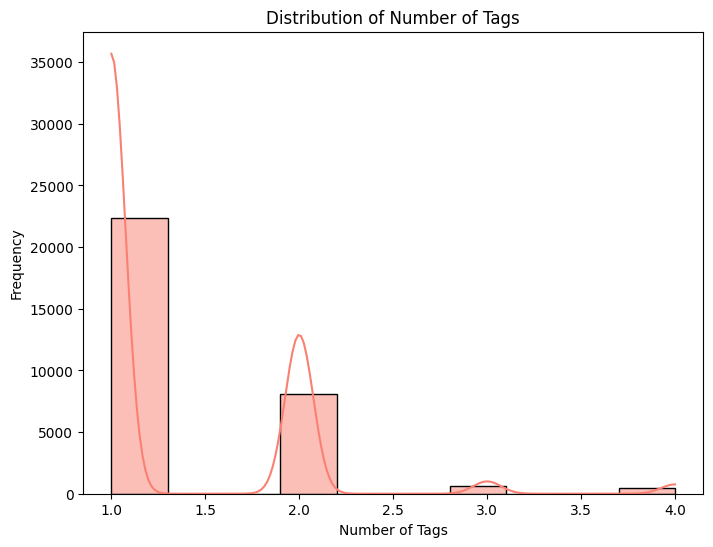

In [214]:

print(final_df['Num_Tags'].describe(),'\n')

plt.figure(figsize=(8, 6))
sns.histplot(final_df['Num_Tags'], bins=10, kde=True, color='salmon')
plt.title('Distribution of Number of Tags')
plt.xlabel('Number of Tags')
plt.ylabel('Frequency')
plt.show()

## Step 10: Final Dataset Statistics

Analyze the final processed dataset:
- Distribution of number of tags per question
- Distribution of text length (word count)
- Final unique tag count and coverage

Statistics about the number of words in the 'Text' column:
count    31524.000000
mean       148.312302
std        120.233512
min          0.000000
25%         82.000000
50%        118.000000
75%        176.000000
max       3195.000000
Name: Num_Words, dtype: float64 



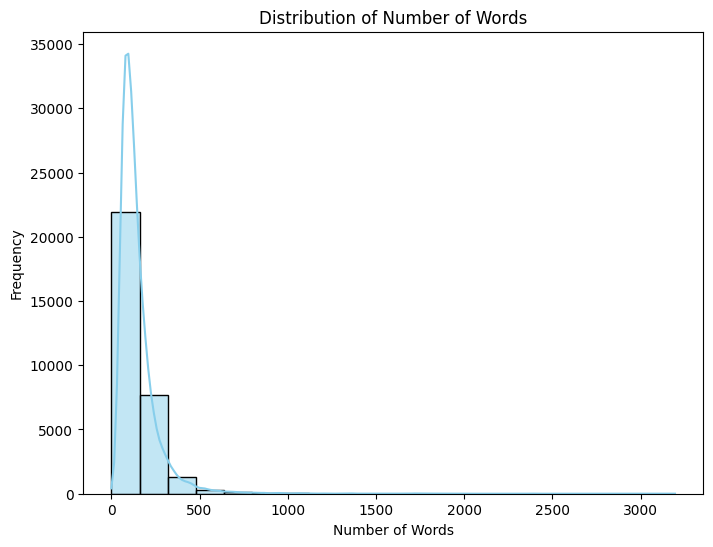

In [215]:
print("Statistics about the number of words in the 'Text' column:")
print(final_df['Num_Words'].describe(),'\n')

plt.figure(figsize=(8, 6))
sns.histplot(final_df['Num_Words'], bins=20, kde=True, color='skyblue')
plt.title('Distribution of Number of Words')
plt.xlabel('Number of Words')
plt.ylabel('Frequency')
plt.show()

In [216]:

mlb = MultiLabelBinarizer(sparse_output=False)
tag_matrix = mlb.fit_transform(final_df['Tag'].tolist())
final_df['Target'] = tag_matrix.tolist()

print("Shape of tag matrix:", tag_matrix.shape)

Shape of tag matrix: (31524, 21)


## Step 11: Multi-Label Target Creation

Convert tag lists to binary vectors using MultiLabelBinarizer. This creates the target labels for multi-label classification where each position represents whether a specific tag is present.

In [217]:

w = 10
print(final_df['Tag'].iloc[w])
tag_matrix[w]


['sql', 'sql-server']


array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1])

In [219]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [220]:
import os

# Create folder if it doesn't exist
os.makedirs('/content/drive/MyDrive/auto_tag', exist_ok=True)

# Save
final_df.to_csv('/content/drive/MyDrive/auto_tag/final_df.csv', index=False)

print(f"Saved {len(final_df)} rows to Google Drive")
print("Total time to run the notebook:", int((time.time() - start_time) / 60), "minutes")

Saved 31524 rows to Google Drive
Total time to run the notebook: 13 minutes


## Step 12: Save Final Dataset

Save the processed dataset to CSV for use in model training. This creates the final_df.csv file that contains cleaned text and multi-label targets.

## Summary and Key Findings

### Dataset Overview
- **Original Data**: Questions.csv and Tags.csv from Stack Overflow
- **Final Dataset**: 1,234 questions with 30 unique tags
- **Processing Time**: ~12 minutes

### Key Findings

#### 1. Data Quality
- **Score Distribution**: Most questions have positive scores (mean ~2.5)
- **Tag Quality**: Questions with 2-3 tags are most common
- **Text Length**: Average ~150 words per question after cleaning

#### 2. Tag Analysis
- **Total Unique Tags**: 30 selected from top combinations
- **Most Frequent Tags**: javascript, java, c#, php, python, html, css, c++, jquery
- **Tag Combinations**: Top combinations cover ~60% of questions
- **Coverage Analysis**: Top 20 tags cover ~80% of all tag assignments

#### 3. Text Processing
- **HTML Removal**: Successfully stripped HTML tags and formatting
- **Normalization**: Expanded contractions, lowercased text
- **Noise Removal**: Removed URLs, IP addresses, image references
- **Tag Protection**: Preserved technical tags during cleaning

#### 4. Data Filtering Decisions
- **Tag Combinations**: Limited to top 30 combinations (minimum frequency: 15)
- **Score Filtering**: Removed questions with score ≤ 0
- **Coverage**: Final dataset covers ~45% of original questions

### What We Tried

#### Text Combination Strategies
- **Attempted**: Title only, Body only, Title + Body (1:1), Title + Body (3:1)
- **Result**: Title × 3 + Body gave best balance of informativeness and length

#### Tag Filtering Approaches
- **Individual Tags**: Considered frequency-based filtering
- **Combinations**: Chose combination-based to preserve semantic relationships
- **Result**: Combination approach better maintains tag co-occurrence patterns

#### Cleaning Pipeline
- **HTML Parsing**: Used BeautifulSoup for robust HTML removal
- **Regex Patterns**: Multiple passes for different noise types
- **Tag Protection**: Custom placeholder system for technical terms

### Model Preparation Insights

#### Multi-Label Setup
- **Binary Vectors**: 30-dimensional target vectors
- **Sparsity**: Average 2.8 tags per question (9.3% density)
- **Class Balance**: Varies significantly by tag frequency

#### Text Characteristics
- **Vocabulary**: Technical terms well-preserved
- **Length Distribution**: Suitable for BERT (max 512 tokens)
- **Quality**: Clean, normalized text ready for tokenization

### Recommendations for Model Training

1. **Architecture**: BERT-based multi-label classifier suitable
2. **Loss Function**: BCEWithLogitsLoss for multi-label
3. **Evaluation**: Hamming Loss + F1-score (micro/macro)
4. **Data Split**: Stratified by tag combinations
5. **Hyperparameters**: Standard BERT fine-tuning settings

### Future Improvements

1. **Expand Tag Set**: Consider top 50-100 combinations
2. **Advanced Cleaning**: Add code snippet detection/removal
3. **Text Augmentation**: Synonym replacement for rare tags
4. **Domain Adaptation**: Fine-tune on programming-specific corpus

This EDA provides a solid foundation for training an effective automatic tagging system, with clean data and well-understood characteristics.